# Equal-Weight Portfolio Bootstrap Analysis

This notebook analyzes hedge fund data to:
1. Filter funds with complete data from 2020 to end of 2025.
2. Randomly select funds to form an equal-weight portfolio.
3. Compute various performance metrics (Mean return, CAGR, Volatility, Mean/Std, Max Drawdown, Calmar Ratio, Correlation with S&P 500).
4. Bootstrap this process 1000 times.
5. Evaluate how portfolio performance metrics change with varying portfolio sizes.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [14]:
# Load data
df = pd.read_csv('data/time_series_jpm_renamed.csv', index_col=0, parse_dates=True)

# Load S&P 500 data
sp500 = pd.read_csv('data/hf_returns/sp500.csv', index_col=0, parse_dates=True)

# Filter for the date range: 2020-01-01 to 2025-12-31
start_date = '2020-01-01'
end_date = '2025-12-31'

# Slice the data
df_period = df.loc[start_date:end_date]
sp500_period = sp500.loc[start_date:end_date]['SP500TR']

# Check for funds that have ALL their data (no NaNs) in this period
# Drop columns that have any NaN values
funds_complete_data = df_period.dropna(axis=1, how='any')

print(f"Total funds with complete data from {start_date} to {end_date}: {funds_complete_data.shape[1]}")

Total funds with complete data from 2020-01-01 to 2025-12-31: 348


In [15]:
def calculate_metrics(returns, sp500_returns):
    """
    Calculate portfolio metrics from a series of monthly returns.
    """
    # 1. Mean Return (Annualized)
    mean_return_ann = returns.mean() * 12
    
    # 2. CAGR
    cum_return = (1 + returns).prod()
    n_years = len(returns) / 12
    cagr = cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan
    
    # 3. Volatility (Annualized)
    volatility = returns.std() * np.sqrt(12)
    
    # 4. Mean / Std (Sharpe Ratio Proxy)
    mean_std_ratio = returns.mean() / returns.std() if returns.std() != 0 else np.nan
    
    # 5. Max Drawdown
    cum_index = (1 + returns).cumprod()
    running_max = cum_index.cummax()
    drawdown = (cum_index - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # 6. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    # 7. Correlation with S&P 500
    correlation = returns.corr(sp500_returns)
    
    return {
        'Mean Return (Ann)': mean_return_ann,
        'CAGR': cagr,
        'Volatility (Ann)': volatility,
        'Mean/Std': mean_std_ratio,
        'Max Drawdown': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Correlation with SP500': correlation
    }

In [16]:
# Bootstrap 1000 portfolios for n=10
np.random.seed(42) # For reproducibility
n_bootstraps = 1000
n_funds_to_select = 10

bootstrap_results = []
columns_available = funds_complete_data.columns.tolist()

if len(columns_available) < n_funds_to_select:
    print("Not enough funds with complete data to form the portfolio!")
else:
    for i in range(n_bootstraps):
        # Randomly select 10 funds
        selected_funds = np.random.choice(columns_available, size=n_funds_to_select, replace=False)
        
        # Compute equal weight return for the portfolio
        portfolio_returns = funds_complete_data[selected_funds].mean(axis=1)
        
        # Compute metrics
        metrics = calculate_metrics(portfolio_returns, sp500_period)
        bootstrap_results.append(metrics)

results_df = pd.DataFrame(bootstrap_results)
results_df.head()

,Mean Return (Ann),CAGR,Volatility (Ann),Mean/Std,Max Drawdown,Calmar Ratio,Correlation with SP500
0,0.076788,0.078012,0.053892,0.411320,-0.059681,1.307153,0.625673
1,0.093753,0.096164,0.056582,0.478314,-0.070667,1.360803,0.518252
2,0.074508,0.075508,0.055102,0.390341,-0.049386,1.528943,0.269292
3,0.090004,0.092510,0.049358,0.526401,-0.054237,1.705675,0.537530
4,0.113201,0.116470,0.071224,0.458810,-0.108012,1.078305,0.644057


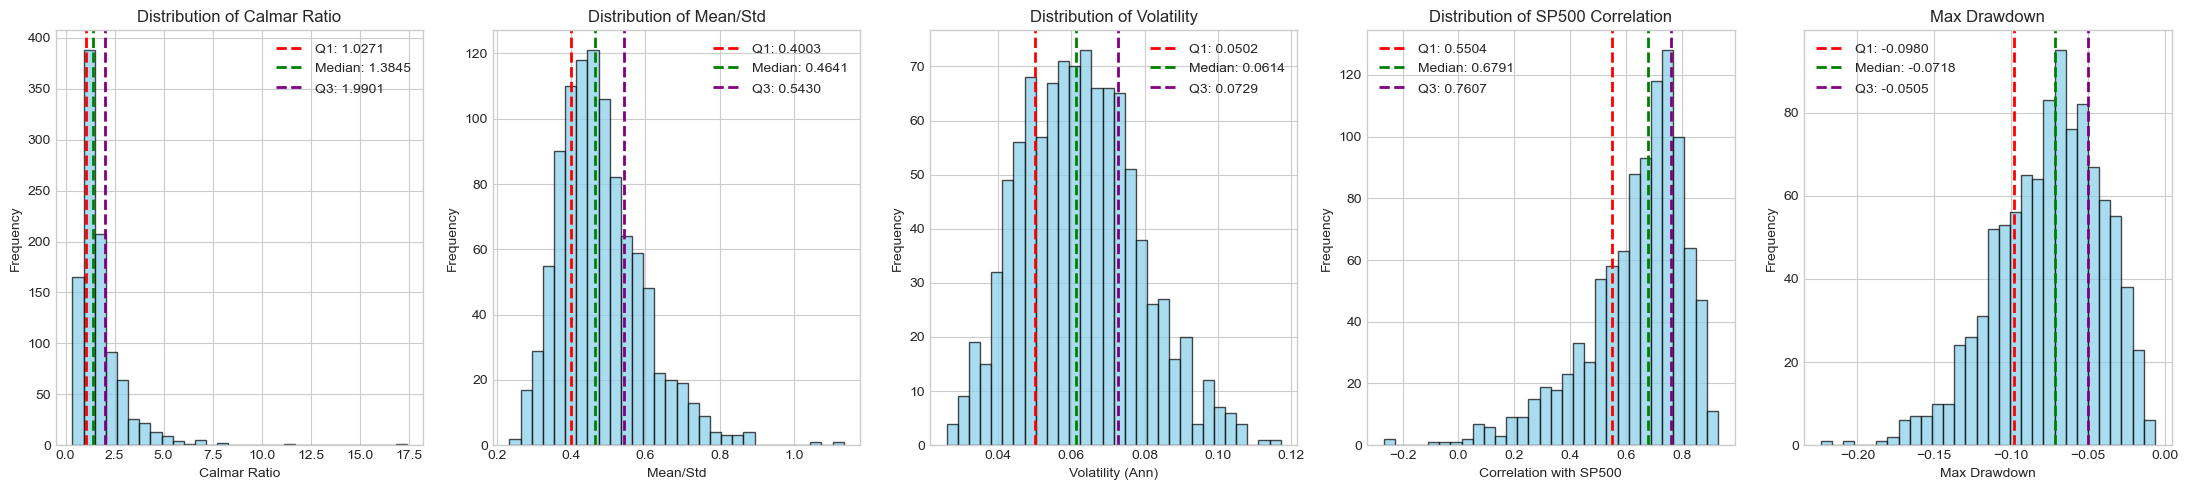

In [17]:
# Plot the distributions for n=10
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

metrics_to_plot = ['Calmar Ratio', 'Mean/Std', 'Volatility (Ann)', 'Correlation with SP500', 'Max Drawdown']
titles = ['Distribution of Calmar Ratio', 'Distribution of Mean/Std', 'Distribution of Volatility', 'Distribution of SP500 Correlation', 'Max Drawdown'] 


for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    data = results_df[metric].dropna()
    
    # Plot histogram
    ax.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Compute quartiles and median
    q1 = data.quantile(0.25)
    median = data.median()
    q3 = data.quantile(0.75)
    
    # Add vertical lines
    ax.axvline(q1, color='red', linestyle='dashed', linewidth=2, label=f'Q1: {q1:.4f}')
    ax.axvline(median, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median:.4f}')
    ax.axvline(q3, color='purple', linestyle='dashed', linewidth=2, label=f'Q3: {q3:.4f}')
    
    ax.set_title(titles[i])
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

## Iterating Over Portfolio Size ($n$)

In this section, we vary the number of funds in our equal-weight portfolio ($n$) from 3 to 15. 
For each $n$, we run 1000 bootstrap simulations.
Then, we extract the **3rd quartile** (for Calmar Ratio, Mean/Std, and Volatility) and the **1st quartile** (for SP500 Correlation) to observe how these specific quartile metrics scale with the portfolio size.

In [18]:
n_values = range(3, 30)

# Dictionaries to store the quartile results for each n
q_results = {
    'Calmar Ratio (Q3)': [],
    'Mean/Std (Q3)': [],
    'Volatility (Ann) (Q3)': [],
    'Correlation with SP500 (Q1)': []
}

np.random.seed(42) # For reproducibility

for n in n_values:
    bootstrap_results_n = []
    
    for i in range(n_bootstraps):
        selected_funds = np.random.choice(columns_available, size=n, replace=False)
        portfolio_returns = funds_complete_data[selected_funds].mean(axis=1)
        metrics = calculate_metrics(portfolio_returns, sp500_period)
        bootstrap_results_n.append(metrics)
        
    df_n = pd.DataFrame(bootstrap_results_n)
    
    # Store the specific quartiles
    q_results['Calmar Ratio (Q3)'].append(df_n['Calmar Ratio'].quantile(0.75))
    q_results['Mean/Std (Q3)'].append(df_n['Mean/Std'].quantile(0.75))
    q_results['Volatility (Ann) (Q3)'].append(df_n['Volatility (Ann)'].quantile(0.75))
    q_results['Correlation with SP500 (Q1)'].append(df_n['Correlation with SP500'].quantile(0.25))

# Convert results to DataFrame for easy plotting
q_results_df = pd.DataFrame(q_results, index=n_values)
q_results_df.index.name = 'Number of Funds (n)'
q_results_df.head()

,Calmar Ratio (Q3),Mean/Std (Q3),Volatility (Ann) (Q3),Correlation with SP500 (Q1)
Number of Funds (n),,,,
3,1.529511,0.449583,0.099081,0.274951
4,1.669242,0.470706,0.095006,0.359609
5,1.726840,0.488168,0.085532,0.386403
6,1.813946,0.500419,0.082545,0.414596
7,1.992431,0.519516,0.077952,0.473619


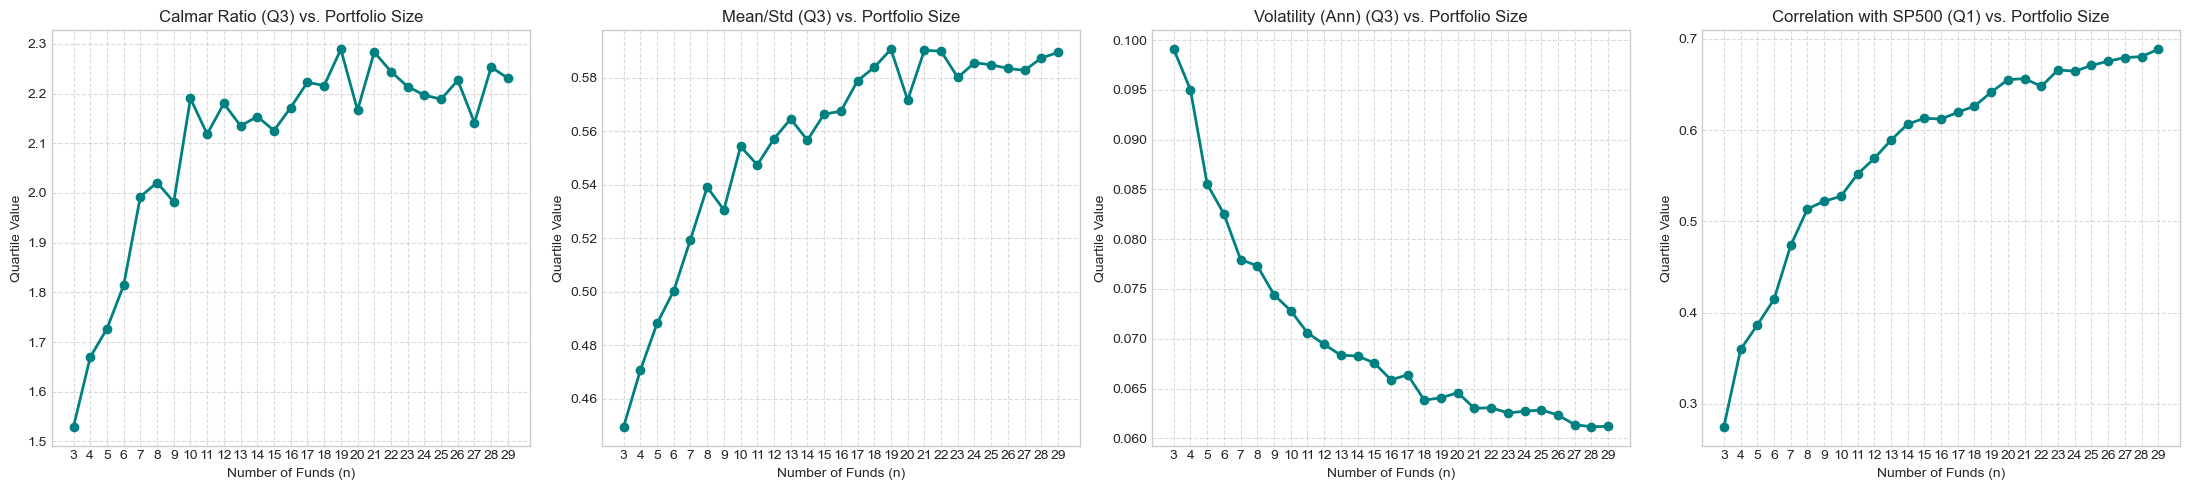

In [19]:
# Plot the scaling results
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

metrics_q_to_plot = [
    'Calmar Ratio (Q3)', 
    'Mean/Std (Q3)', 
    'Volatility (Ann) (Q3)', 
    'Correlation with SP500 (Q1)'
]

for i, metric in enumerate(metrics_q_to_plot):
    ax = axes[i]
    ax.plot(q_results_df.index, q_results_df[metric], marker='o', linestyle='-', color='teal', linewidth=2)
    
    ax.set_title(f'{metric} vs. Portfolio Size')
    ax.set_xlabel('Number of Funds (n)')
    ax.set_ylabel('Quartile Value')
    ax.set_xticks(list(n_values))
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()